In [1]:
import mlflow
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from collections import defaultdict

import sys
sys.path.insert(0, "../../run")
from const import REPO_PATH
from experiment_config import TRAINGING_CONFIG

sys.path.insert(1, f"{REPO_PATH}")
from src.model.experiment_utils import *
from src.model.model_utils import *

In [2]:
features_path = f"{TRAINGING_CONFIG['features_path']}/all_combined_features_2017-24.csv"
output_dir = f"{REPO_PATH}/models/ml_models"

In [3]:
seasons=sorted(TRAINGING_CONFIG['seasons'])
target_dfs=[pd.read_csv(f"{TRAINGING_CONFIG['processed_data_path']}/{season}/all_target_df.csv") for season in seasons[1:]]
for df in target_dfs:
    df['date']= pd.to_datetime(df['date'])
target_df = pd.concat(target_dfs, ignore_index=True)
target_columns=target_df.drop(columns=TRAINGING_CONFIG['key_columns']).columns.tolist()

In [4]:
feature_df = pd.read_csv(features_path)
feature_df['date']= pd.to_datetime(feature_df['date'])
feature_df, target_df=align_on_keys(feature_df, target_df, TRAINGING_CONFIG['key_columns'])

In [5]:
numeric_cols = feature_df.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()
feature_df[numeric_cols] = scaler.fit_transform(feature_df[numeric_cols])

In [6]:
mlp_param_grid = {
    'hidden_layer_sizes': [(128, 32), (64, 32, 32)],
    'activation': ['relu'],
    'solver': ['adam'],
    'alpha': [0.001, 0.1],
    'learning_rate_init': [0.001, 0.01],
    'batch_size': [16, 32, 64],
    'max_iter': [1000],
}

xgb_param_grid = {
    'n_estimators': [100,],
    'max_depth': [3,],
    'learning_rate': [0.01,],
    'gamma': [0],
    'reg_alpha': [0],
    'reg_lambda': [5],
}

lightgbm_param_grid = {
    'n_estimators': [100, ],
    'learning_rate': [0.01],
    'max_depth': [3],
    'num_leaves': [15],
    'subsample': [0.8],
    'verbose': [-1]
}

In [7]:
feature_df.fillna(-1, inplace=True)

In [8]:
run_multiclass_distribution_experiment(
    feature_df=feature_df,
    target_df=target_df,
    target_ranges=TRAINGING_CONFIG['target_ranges'],
    model_wrapper_class=lambda **params: SklearnWrapper(XGBClassifier, **params),
    model_param_grid=xgb_param_grid,
    test_size=TRAINGING_CONFIG['test_size'],
    k=5,
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    uri=f'{REPO_PATH}/mlflow',
    model_name='XGBClassifier',
    key_columns=TRAINGING_CONFIG['key_columns'],
    save_model_path=TRAINGING_CONFIG['save_model_path']
)


Training XGBClassifier on home_goals with param grid: {'n_estimators': [100], 'max_depth': [3], 'learning_rate': [0.01], 'gamma': [0], 'reg_alpha': [0], 'reg_lambda': [5]}
Using range-based class conversion with range: (0, 5)
Training fold 1/5 with params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'reg_alpha': 0, 'reg_lambda': 5}
Training fold 2/5 with params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'reg_alpha': 0, 'reg_lambda': 5}
Training fold 3/5 with params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'reg_alpha': 0, 'reg_lambda': 5}
Training fold 4/5 with params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'reg_alpha': 0, 'reg_lambda': 5}
Training fold 5/5 with params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'reg_alpha': 0, 'reg_lambda': 5}
{'home_goals_train_accuracy': 0.6651461988304094, 'home_goals_train_precision': 0.8660853

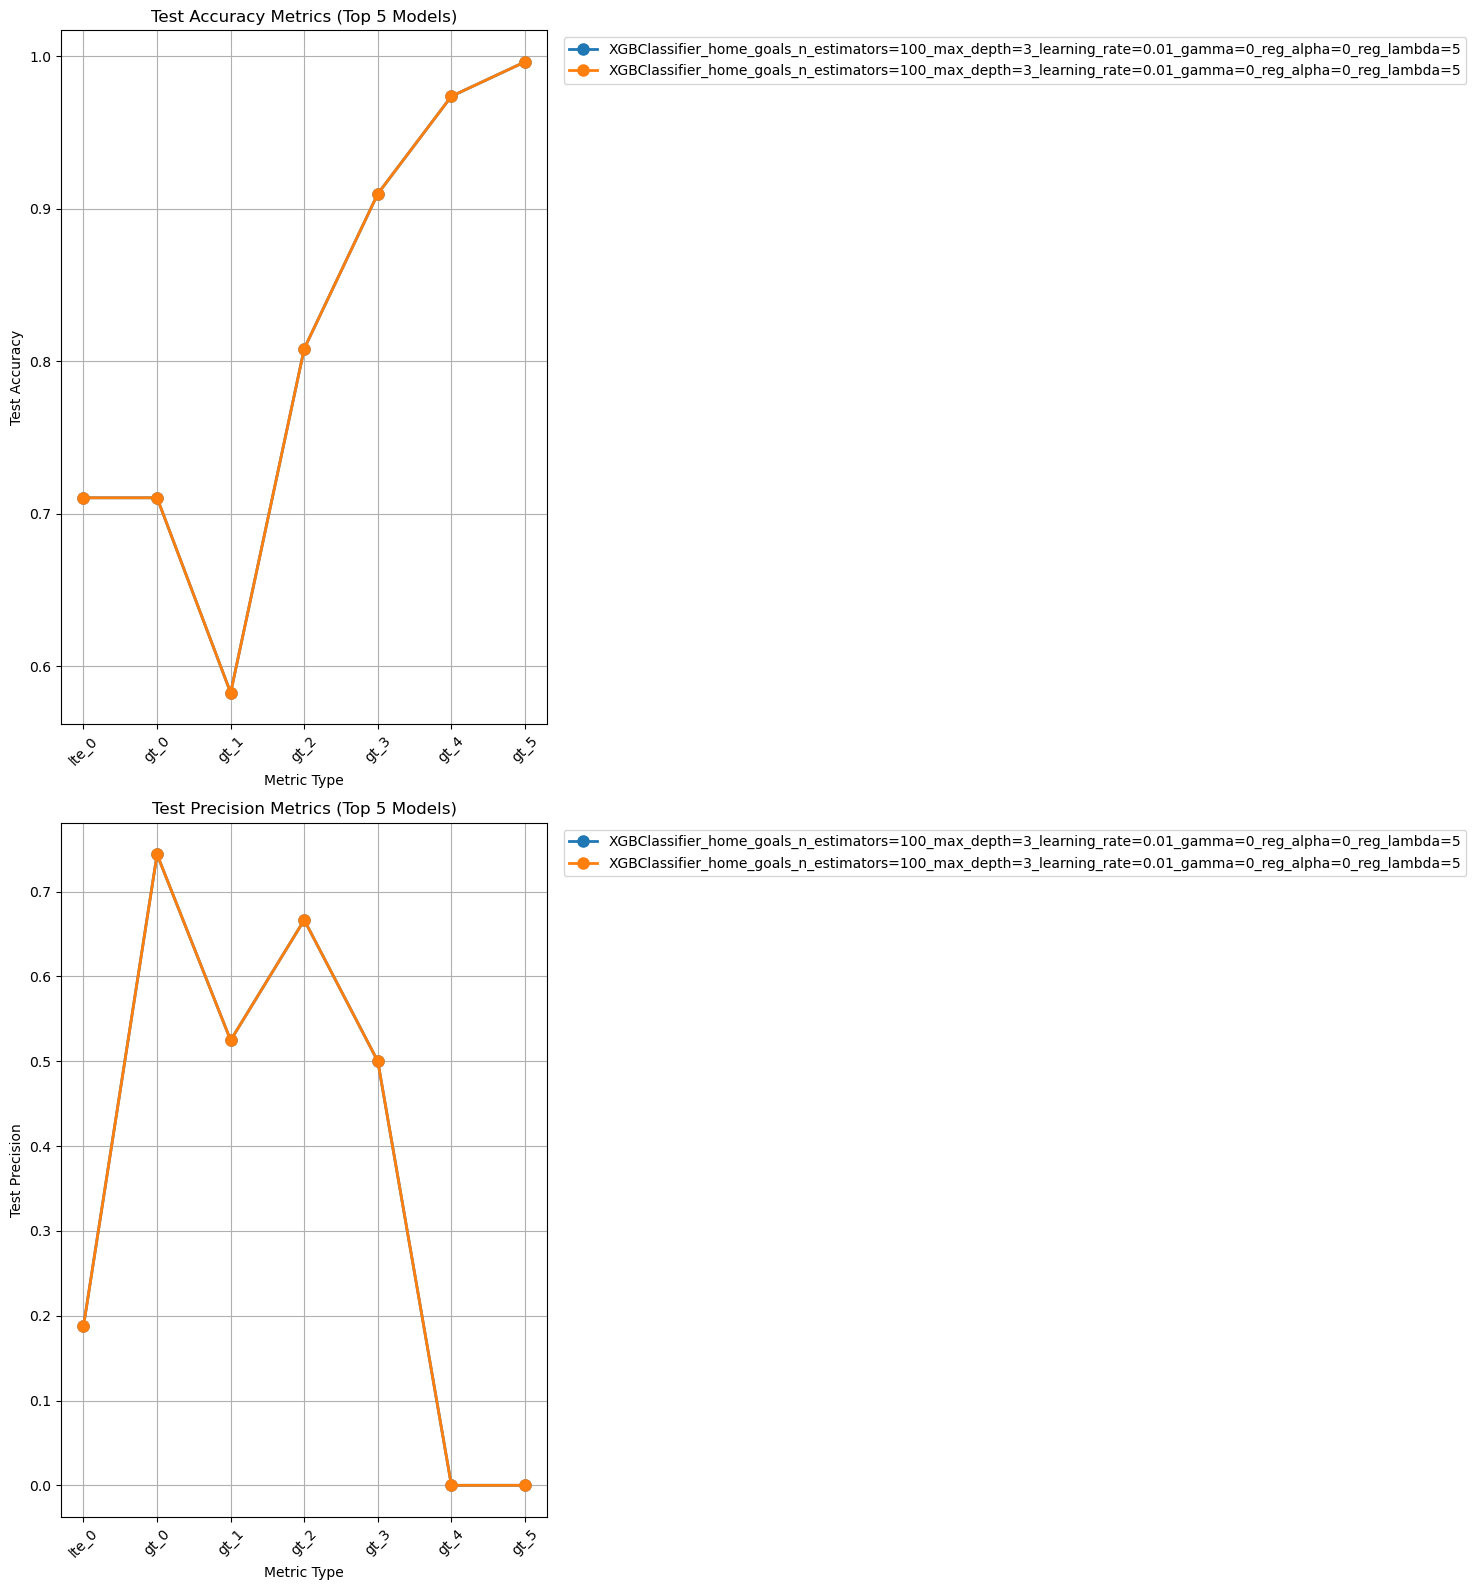

In [9]:
plot_metrics_for_target_and_model(
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    target_col="home_goals",
    model_name="XGBClassifier",
    tracking_uri=f"{REPO_PATH}/mlflow"
)

In [10]:
plot_run_metrics_by_split(experiment_name=TRAINGING_CONFIG['experiment_name'],
                         run_name="XGBClassifier_home_goals_n_estimators=100_max_depth=3_learning_rate=0.1_gamma=1_reg_alpha=0_reg_lambda=5",
                         target_col="home_goals",
                         tracking_uri=f"{REPO_PATH}/mlflow")

No run found with name 'XGBClassifier_home_goals_n_estimators=100_max_depth=3_learning_rate=0.1_gamma=1_reg_alpha=0_reg_lambda=5'.


In [11]:
plot_run_metrics_side_by_side(experiment_name=TRAINGING_CONFIG['experiment_name'],
                              model_name="XGBClassifier",
                              model_param={'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0},
                              tracking_uri=f"{REPO_PATH}/mlflow",
                              metric_type="precision")

Searching for runs with filter: params.model_name = 'XGBClassifier' and params.n_estimators= '100' and params.max_depth= '5' and params.learning_rate= '0.01' and params.gamma= '0'
No runs found with model_name 'XGBClassifier' and params {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0}.
